# 03 Baseline Model

Training a Linear Regression as the baseline model using the cleaned .csv from Week 3.

Testing Month: May 2026

## Set Up & Load

- Similar imports as used in previous files
- data pulled from local machine, cleaned .csv file is not available in public github repository

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

In [2]:
TEST_MONTH = "2026-05" #most recent month 
TRAIN_MONTHS = 5 #tbd = preceding months

DATA = "../../data/cleaned_CRMLSSold202512_202605.csv" 
DATE = "CloseDate"
TARGET = "ClosePrice"

#display formatting:
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid")

In [3]:
# load data

df = pd.read_csv(DATA, parse_dates=[DATE])

print(f"Shape: {df.shape}")
print("Months:", sorted(df[DATE].dt.to_period("M").astype(str).unique()))
print(f"Date range: {df[DATE].min().date()} -> {df[DATE].max().date()}")

# sanity checking
assert df[TARGET].isna().sum() == 0, "Target has missing values"
assert (df[TARGET] > 0).all(), "Impossible price values in target"
assert df[DATE].isna().sum() == 0, "Date column has missing values"
assert df[DATE].dt.to_period("M").astype(str).max() == TEST_MONTH, (f"Latest month in data != TEST_MONTH ({TEST_MONTH})")
print("All sanity checks passed.")

Shape: (61604, 77)
Months: ['2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05']
Date range: 2025-12-01 -> 2026-05-31
All sanity checks passed.


## Chronological Train/Test Split
- Test Month: May 2026
- Training Set: X months preceding test month
- X is tunable

In [4]:
#split data into train/test sets

def chrono_split(data, test_month=TEST_MONTH, window=TRAIN_MONTHS, date=DATE):

      months = data[date].dt.to_period("M")
      test_p = pd.Period(test_month, freq="M")
      train_start = test_p - window 

      test = data[months == test_p]
      train = data[(months >= train_start) & (months < test_p)]
      # Error checks
      assert len(train) > 0 and len(test) > 0, "ERROR: Empty split (check params)"
      assert train[date].max() < test[date].min(), "Chronology violated"
      return train, test


train_df, test_df = chrono_split(df)

print(f"Train: {train_df.shape[0]:,} rows "f"({train_df[DATE].min().date()} -> {train_df[DATE].max().date()})")
print(f"Test:  {test_df.shape[0]:,} rows "f"({test_df[DATE].min().date()} -> {test_df[DATE].max().date()})")

Train: 49,597 rows (2025-12-01 -> 2026-04-30)
Test:  12,007 rows (2026-05-01 -> 2026-05-31)


## Market Drift Check

- quantifying the difference between markets across the various time frames of the input csv (December to May)

<Axes: title={'center': 'Median ClosePrice by month'}, xlabel='CloseDate'>

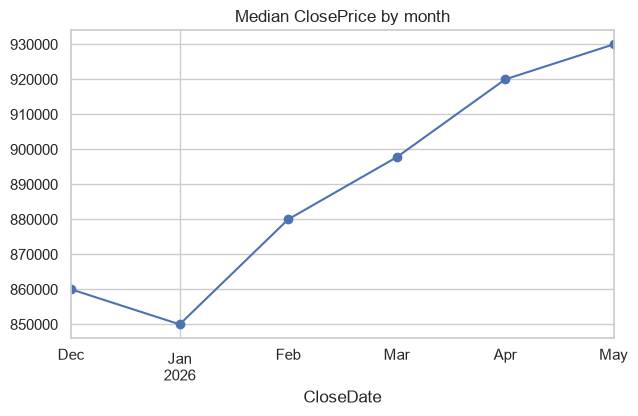

In [5]:
monthly = df.groupby(df[DATE].dt.to_period("M"))[TARGET].agg(["median", "count"])
monthly["median"].plot(marker="o", figsize=(7, 4), title="Median ClosePrice by month")

Interpret:

- The graph visualizes the differences in ClosePrice median that takes place between the months from December to May.
- As spring approaches, the median price of the single family residence properties also became more expensive
- The lowest ClosePrice median was documented during January (2026)
- The Testing month for this task is May 2026 which is also the most expensive month of the preceding months
- Training uses preceding months that are cheaper than Testing Month

The comparison of median between the preceding months to the testing month reveal that the residuals to be perform will probably under predict May, with a likely positive skew.
 

## Feature Selection
- determining a reference category
- exclusions (inclusions list is way too long)
    - date columns
    - target variable (and variations of) since feature must be knowable at query
    - CountyOrParish to avoid double counts
    - Raw variables where the log version is utilized for model
    - PostalCode 



In [6]:
# determining a reference county based on number of listings in the cleaned csv
df["CountyOrParish"].value_counts().head(10)

CountyOrParish
Los Angeles        15199
Riverside           9716
San Diego           6879
San Bernardino      6617
Orange              5936
Contra Costa        2786
Alameda             2717
Ventura             2038
Santa Clara         1768
San Luis Obispo     1070
Name: count, dtype: int64

LA county based on sales is the largest county and will be set as a good reference, thus is dropped.

In [7]:
EXCLUDE = [
    "ListingKey",              
    "CloseDate", "CloseMonth",  

    "ClosePrice",               # target var
    "ClosePrice_log",           # target in log form
    "ClosePrice_repaired",      # metadata

    "CountyOrParish",           # one-hots from 02_preprocessing cleaned csv
    "PostalCode",               

    "LivingArea",               # using LivingArea_log
    "LotSizeAcres",             # using LotSizeAcres_log

    "County_Los_Angeles",       # reference

]

feature = [c for c in df.columns if c not in EXCLUDE]
print(f"{len(feature)} features")

# Checks
assert not any("ClosePrice" in c for c in feature), ("Target column leaked")
assert df[feature].isna().sum().sum() == 0, ("Feature matrix contains NaNs")

66 features


## Scaling
- spliting into x/y
- standardizing to fit on training data to make coeffs comparable

In [8]:
#X
X_train = train_df[feature]
X_test = test_df[feature]

#
y_train = train_df[TARGET]
y_test = test_df[TARGET]

# Scale
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=feature, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=feature, index=X_test.index)

X_train_s.describe().loc[["mean", "std"]].T.head(8)

,mean,std
BedroomsTotal,-0.0000,1.0000
BathroomsTotalInteger,0.0000,1.0000
LotSizeAcres_imputed,0.0000,1.0000
ViewYN,0.0000,1.0000
BasementYN,0.0000,1.0000
PoolPrivateYN,0.0000,1.0000
AttachedGarageYN,-0.0000,1.0000
FireplaceYN,0.0000,1.0000


## Baseline Model

Testing predictions on ClosePrice in both raw form and log form for more thorough visualization. Also reverifies the EDA result in which log of the target variable is better for modeling.

- predict() plugs in the property feature values

Both models fitted.


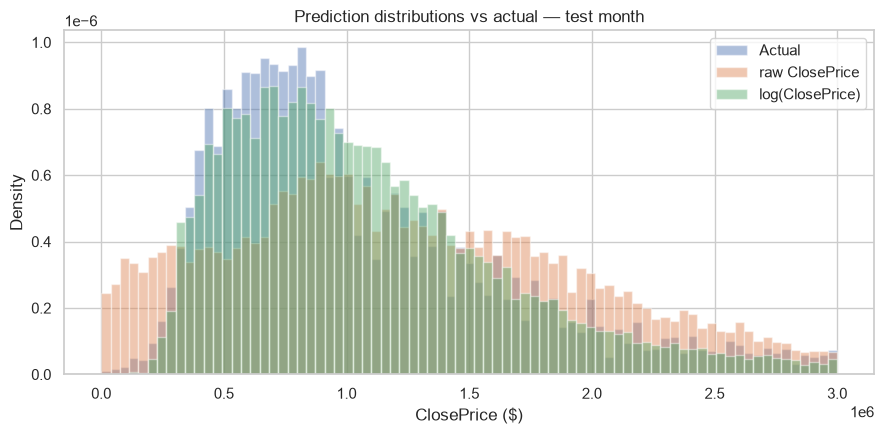

Checking for impossible floors in predictions:
Raw model min prediction: $-821,582
Log model min prediction: $119,294


In [9]:
# baseline variants

# ClosePrice (raw)
model_raw = LinearRegression()
model_raw.fit(X_train_s, y_train)
pred_raw_train = model_raw.predict(X_train_s)
pred_raw_test = model_raw.predict(X_test_s)

# log(ClosePrice)
model_log = LinearRegression()
model_log.fit(X_train_s, np.log(y_train))
pred_log_train = np.exp(model_log.predict(X_train_s))
pred_log_test = np.exp(model_log.predict(X_test_s))

#check
print("Both models fitted.")

# comparing prediction distributions vs the actual (test set)
fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.linspace(0, 3_000_000, 80)   # focus on the bulk; tail clipped for readability
ax.hist(y_test, bins=bins, alpha=0.45, label="Actual", density=True)
ax.hist(pred_raw_test, bins=bins, alpha=0.45, label="raw ClosePrice", density=True)
ax.hist(pred_log_test, bins=bins, alpha=0.45, label="log(ClosePrice)", density=True)
ax.set_xlabel("ClosePrice ($)")
ax.set_ylabel("Density")
ax.set_title("Prediction distributions vs actual — test month")
ax.legend()
plt.tight_layout()
plt.show()

#check for impossible floors
print("Checking for impossible floors in predictions:")
print(f"Raw model min prediction: ${pred_raw_test.min():,.0f}")
print(f"Log model min prediction: ${pred_log_test.min():,.0f}")

### Interpretation:

- Graph:
    - The raw value distribution is very flat compared to the actual distribution 
    - The log value is much more similar to the actual distribution
- Check for impossible values:
    - The raw model predicts a negative value (−$821,582) which means the seller is paying the buyer for the property (impossible).
    - The log model predicts a positive value (will always have a positive), which is realistic ($119,294).

As expected from the EDA, the log model of ClosePrice is be the baseline target variable to be used.

## Evaluate 
- R^2 in dollar predictions for both models of raw and log ClosePrice
- using median style estimates
- training R^2 on benchmarks against the mean of training prices

In [10]:
results = pd.DataFrame({
    "target": ["raw ClosePrice", "log ClosePrice"],
    "train_r2": [r2_score(y_train, pred_raw_train), r2_score(y_train, pred_log_train)],
    "test_r2": [r2_score(y_test, pred_raw_test), r2_score(y_test, pred_log_test)],
})

results["train_test_gap"] = results["train_r2"] - results["test_r2"]
results

,target,train_r2,test_r2,train_test_gap
0,raw ClosePrice,0.4477,0.3094,0.1383
1,log ClosePrice,0.5425,0.3325,0.2100


### Interpret:
- log of ClosePrice yields stronger results on training predictions (again confirms that we should use the log variation)
- testing result reveals the modest behind using county as a location signal (can be refined later on)
- log has a larger train/test gap since the train fit is higher

- R_2 unchanged after excluding the reference county (LA county) which confirms that the dummy was redundant

## Coefficient Interpretation

- standardize coefficients then sorted by dollar effects

In [ ]:
coefs = pd.DataFrame({
    "feature": feature,
    "$_change_per_SD_r_model": model_raw.coef_,
    "%_change_per_SD_lg_model": model_log.coef_ * 100,
})

coefs["abs_raw"] = coefs["$_change_per_SD_r_model"].abs()
coefs = coefs.sort_values("abs_raw", ascending=False).drop(columns="abs_raw")

coefs.head(15) 

,feature,$_change_per_SD_r_model,%_change_per_SD_lg_model
1,BathroomsTotalInteger,"649,780.1144",15.3045
64,LivingArea_log,"328,736.5492",29.4613
39,County_Riverside,"-259,071.2192",-21.6925
0,BedroomsTotal,"-214,344.1618",-6.8781
42,County_San_Bernardino,"-199,364.5391",-20.2725
49,County_Santa_Clara,"161,569.7446",9.7507
47,County_San_Mateo,"146,380.4699",7.8642
6,AttachedGarageYN,"-128,342.6360",-4.3259
35,County_Orange,"111,105.5381",6.8921
11,County_Butte,"-81,945.9934",-9.9619


### Interpret:

- Two strongest drivers split by column:
    - LivingArea_log: strongest percent driver (+29.5%/SD) (market-wide effect)
    - BathroomsTotalInteger: strongest dollar driver (+$650k/SD) 
        - raw column is weighted toward expensive homes (squared dollar errors), where bath counts scale hard
- Size trio (bath/bed/living) is intercorrelated; shares credit and story should be read jointly
- County coeffs vs LA county reference: 
    - Bay Area premium (Santa Clara +$161k, San Mateo +$146k) 
    - Inland Empire discount (Riverside −$259k, San Bernardino −$199k)
- BedroomsTotal negative (−$214k/SD):
    - a partial result 
    - square footage cut into more bedrooms which the area already carries the value
- AttachedGarageYN negative (−$128k):
    - conditional result
    - homes lacking attached garages skew older/urban/luxury (detached garages)
- Per-SD dummy ranking favors high-vol counties while small-SD rare-county dummies shrink
    - county rows directional only

## Residual Diagnostics

## Results